# Dynamic Verification — Conforming Crack with Traction Law

Same structure as `dynamic_verification_uncoupled.ipynb`, but with a **mesh-fitted (conforming) straight crack** and a user-selectable spring + dashpot traction law.  Biot coupling is kept off (`α = 0`) so the pressure field stays zero, and the momentum equation reduces to a pure elastic wave problem with an interior interface.

There is no closed-form solution, so we verify the time integrator by

1. tracking the kinetic and strain energies $E_k = \tfrac12 v^T M_v v$ and $E_s = \tfrac12 u^T K_{uu} u$,
2. checking that the total energy is conserved for a purely elastic crack ($\eta_n = \eta_t = 0$) and monotonically decreasing when dashpots are on,
3. visualising the solution with the CG dashboard.

## 1. Imports

In [1]:
import os
os.environ.setdefault('OMP_NUM_THREADS', '8')

import numpy as np
import scipy.sparse as sp
import matplotlib.pyplot as plt

from skfem.models.elasticity import lame_parameters

from poroelasticity import (
    CGPoroelastostatics,
    CrackMeshBuilder,
    CrackModelParams,
)
from poroelasticity.cg_dashboard import CGPoroelasticDashboard

import solve_nivp

print(f"solve_nivp version: {getattr(solve_nivp, '__version__', 'dev')}")
print('Imports OK')

solve_nivp version: dev
Imports OK


## 2. Configuration

`ALPHA_BIOT = 0` decouples fluid and solid.  The crack is a straight line centred at `(CRACK_X0, CRACK_Y0)`, rotated by `CRACK_THETA` from the y-axis, with total length `CRACK_LENGTH`.  `CrackMeshBuilder(..., conforming=True)` builds a Gmsh transfinite quad mesh whose element edges align with the crack.

`RHO_D` overrides the dimensionless density (see the uncoupled verification notebook for why).

In [2]:
# Material (Biot off)
NU          = 0.25
G_SHEAR     = 22e3              # MPa
ETA_FLUID   = 2e-10 / 3600
BETA_FLUID  = 8.5e-5
K_PERM      = 1e-14 * 1e-6
ALPHA_BIOT  = 0.5

# Dimensionless density (bypass diffusion-time nondim)
RHO_D = 1.0

# Domain
L_DOMAIN = 1.0
XMIN, XMAX = -0.5, 0.5
YMIN, YMAX = -0.5, 0.5

# Scales
SCALE_L, SCALE_EPS = 1.0, 1e-3
P_SCALE            = None

# Crack geometry (horizontal half-length crack centred in the box)
CRACK_THETA  = np.pi / 2.0     # horizontal (line makes 90° with y-axis)
CRACK_X0     = 0.0
CRACK_Y0     = 0.0
CRACK_LENGTH = 0.5

# Traction law coefficients (dimensional).  Free knobs for the user.
CRACK_T     = 0.0              # Robin transmissibility (pressure irrelevant with α=0)
CRACK_K_N   = 1.0e8            # normal spring   [MPa/km]
CRACK_K_T   = 1.0e8            # tangent spring  [MPa/km]
CRACK_ETA_N = 0.0              # normal dashpot  [MPa·hr/km]
CRACK_ETA_T = 0.0              # tangent dashpot [MPa·hr/km]

# Mesh + time stepping
N_ELEM           = 24
ENFORCEMENT_TYPE = 'nodal'     # algebraic Lagrange-multiplier enforcement
N_PERIODS        = 1.0         # simulation length expressed in reference periods
STEPS_PER_PERIOD = 160

# BCs: all four walls have zero rate, pressure frozen
BC_V1_RATE = {'left': 0.0, 'right': 0.0}
BC_V2_RATE = {'top': 0.0,  'bottom': 0.0}
BC_DP_RATE = {'left': 0.0, 'right': 0.0, 'top': 0.0, 'bottom': 0.0}

# Initial displacement: broad cosine bump shifted off the crack so it can bounce
WAVE_AMPLITUDE = 1e-3 * SCALE_L
K_WAVE         = np.pi / L_DOMAIN

print(f"Domain:     [{XMIN},{XMAX}] × [{YMIN},{YMAX}], N_ELEM={N_ELEM}")
print(f"Crack:      θ={CRACK_THETA:.3f}, centre=({CRACK_X0},{CRACK_Y0}), length={CRACK_LENGTH}")
print(f"Springs:    k_n={CRACK_K_N:.1e}, k_t={CRACK_K_T:.1e}")
print(f"Dashpots:   η_n={CRACK_ETA_N:.1e}, η_t={CRACK_ETA_T:.1e}")
print(f"rho_d (imposed) = {RHO_D}")

Domain:     [-0.5,0.5] × [-0.5,0.5], N_ELEM=24
Crack:      θ=1.571, centre=(0.0,0.0), length=0.5
Springs:    k_n=1.0e+08, k_t=1.0e+08
Dashpots:   η_n=0.0e+00, η_t=0.0e+00
rho_d (imposed) = 1.0


## 3. Build Conforming Mesh

In [3]:
builder = CrackMeshBuilder(
    XMIN, XMAX, YMIN, YMAX, N_ELEM,
    crack_theta=CRACK_THETA,
    crack_x0=CRACK_X0, crack_y0=CRACK_Y0,
    crack_length=CRACK_LENGTH,
    element_type='tri', conforming=True,
    verbose=True,
)
mesh, el_p, el_u, crack, h = builder.build()
print(f"h ≈ {h:.4f},  elements = {mesh.nelements},  vertices = {mesh.p.shape[1]}")


Conforming tri mesh: 1498 elements, h=0.0417
[RobustCrackGenerator] Conforming shortcut: 12 crack-aligned facets found — using directly
[RobustCrackGenerator] Timing breakdown:
    setup                             17.9 ms
    conforming_check                  37.2 ms
    find_facets_intersected            0.0 ms
    find_elements_intersected          0.0 ms
    get_candidate_facets               0.0 ms
    compute_metrics                    0.0 ms
    path_selection                     0.0 ms
    TOTAL                             55.2 ms
[RobustCrackGenerator] Surrogate facets: 12
  Alignment: mean=1.000, min=1.000
  |δ|/h:    mean=0.000, max=0.000



Mesh: 798 vertices, 1498 elements


Crack: 12 surrogate facets
h = 0.041666666666666664
h ≈ 0.0417,  elements = 1498,  vertices = 798


## 4. Assemble CG Solver

`enforcement_type='nodal'` uses strong / algebraic Lagrange-multiplier enforcement at the crack interface.  `include_sbm=False` because the mesh is conforming — there is nothing to shift.

In [4]:
E_young = 2.0 * G_SHEAR * (1.0 + NU)
lam, mu = lame_parameters(E_young, NU)
params = (mu, lam, ALPHA_BIOT, BETA_FLUID, K_PERM / ETA_FLUID)

crack_model = CrackModelParams(
    T=CRACK_T,
    k_n=CRACK_K_N, k_t=CRACK_K_T,
    eta_n=CRACK_ETA_N or None,
    eta_t=CRACK_ETA_T or None,
)

bc = {
    'v1': {}, 'v2': {},
    'v1_rate': BC_V1_RATE, 'v2_rate': BC_V2_RATE,
    'dp_rate': BC_DP_RATE,
}

poro = CGPoroelastostatics(
    mesh=mesh,
    element_p=el_p,
    element_u=el_u,
    params=params,
    crack=crack,
    crack_model=crack_model,
    intorder=6,
    scales=(SCALE_L, SCALE_EPS),
    bc=bc,
    P_scale=P_SCALE,
    verbose=True,
    free_memory=False,
    enforcement_type=ENFORCEMENT_TYPE,
    apply_transform=True,
    include_taylor=False,
    include_hessian=False,
    include_sbm=False,
    density=1.0,
)

poro.rho_d = float(RHO_D)

print(f"ndofs = {poro.ndofs}")
print(f"  Np = {poro.basis_p.N},  Nu = {poro.basis_u.N}")
print(f"  n_lambda_q = {poro.n_lambda_q},  n_lambda_sigma = {poro.n_lambda_sigma}")
print(f"  transformed_vars = {poro._transformed_vars}")

Mesh split along crack:
  Original: 798 vertices, 1498 elements
  Split: 809 vertices, 1498 elements
  Crack facets: 12 plus, 12 minus


  Projected 0 / 48 QPs with flipped normals for basis <skfem FacetBasis(MeshTri1, ElementTriP1) object>
  Number of elements: 12
  Number of DOFs: 809
  Size: 3456 B
  Projected 0 / 48 QPs with flipped normals for basis <poroelasticity.cg_crack_assembler.FlippedNormalBasis object at 0x7bdf48fc55d0>
  Projected 0 / 48 QPs with flipped normals for basis <skfem FacetBasis(MeshTri1, ElementVector) object>
  Number of elements: 12
  Number of DOFs: 4614
  Size: 18432 B
  Projected 0 / 48 QPs with flipped normals for basis <poroelasticity.cg_crack_assembler.FlippedNormalBasis object at 0x7bdf48fc5590>
SBM geometry cache: 192 QPs pre-computed in 1.9 ms
Crack interface assembled (Spring law + SBM corrections):
  Robin T = 0.00e+00 (dimensionless: 0.00e+00)
  Spring k_n = 100000000.0 (dimensionless: 3.40e+04)
  Spring k_t = 100000000.0 (dimensionless: 3.40e+04)
  Enforcement type: nodal
Nodal enforcement: 11 interface node pairs (2×11 = 22 flux DOFs)
Augmented system assembled: 5489 DOFs
  = 80

## 5. Projection and First-Order Dynamic System

`strip_multiplier_dynamics()` zeros the multiplier rows of `M` so the algebraic projection owns them, `build_projection()` builds the `AlgebraicConstraintProjection`, and `build_first_order_dynamic_system(meta, density=1.0)` lifts the resulting DAE to descriptor form `A_dyn · ẋ = rhs(t, x)` with `x = [z, v]`.

In [5]:
poro.strip_multiplier_dynamics()
projection, meta = poro.build_projection()

dyn = poro.build_first_order_dynamic_system(meta, density=1.0)

A_dyn          = dyn['A']
rhs_dyn        = dyn['rhs']
rhs_jac_dyn    = dyn['rhs_jac']
velocity_slice = dyn['velocity_slice']
n_base         = dyn['n_base']
comp_slices    = dyn['component_slices']
nl_atol_dyn    = dyn['nl_atol_per_block']
atol_dyn       = dyn['atol_per_block']

solver_opts = dict(meta['solver_opts'])
solver_opts['rhs_jac'] = rhs_jac_dyn

# MUMPS via PETSc: direct solver with auto-scaling.
# NOTE: linear_solver must be 'petsc' (not 'MUMPS') — solve_nivp routes
# 'petsc' → PETSc KSP preonly + LU with MUMPS backend.  An unrecognised
# string like 'MUMPS' falls back to ILU+GMRES which cannot handle the
# algebraic-constraint saddle-point structure.
solver_opts['linear_solver'] = 'petsc'
solver_opts['precond_reuse_steps'] = 1_000_000   # constant Jacobian → maximise LU reuse
solver_opts['petsc_options'] = {
    **solver_opts.get('petsc_options', {}),
    'mat_mumps_icntl_23': 0,    # 0 = no memory cap for MUMPS work arrays
}

T_sc, U_sc, P_sc, Sigma_sc, Mmod_sc, Q_sc, VL_sc = poro.get_scales()

mu_d, lam_d, rho_d = float(poro.mu_d), float(poro.lam_d), float(poro.rho_d)
c_p    = np.sqrt((lam_d + 2.0 * mu_d) / rho_d)
k_d    = K_WAVE * SCALE_L
omega  = k_d * c_p
period = 2.0 * np.pi / omega
tmax   = N_PERIODS * period
h_fixed = period / STEPS_PER_PERIOD

print(f"n_base = {n_base},  |x| = {A_dyn.shape[0]},  nnz(A_dyn) = {A_dyn.nnz}")
print(f"reference period = {period:.4e},  tmax = {tmax:.4e},  h = {h_fixed:.4e}")
print(f"linear_solver = {solver_opts['linear_solver']!r}")
print(f"MUMPS ICNTL(8) = {solver_opts['petsc_options'].get('mat_mumps_icntl_8', '(default)')}")
print(f"MUMPS ICNTL(23) = {solver_opts['petsc_options'].get('mat_mumps_icntl_23', '(default)')}")
print(f"precond_reuse_steps = {solver_opts['precond_reuse_steps']}")

build_projection():
  Flux constraint:     C_q shape=(22, 5423)
  Traction constraint: C_s shape=(44, 5423)
  Projection type:     AlgebraicConstraintProjection
  Component slices:    8 blocks


n_base = 5489,  |x| = 10103,  nnz(A_dyn) = 40775
reference period = 4.2220e-01,  tmax = 4.2220e-01,  h = 2.6388e-03
linear_solver = 'petsc'
MUMPS ICNTL(8) = 77
MUMPS ICNTL(23) = 0
precond_reuse_steps = 1000000


### 5a. Descriptor Pencil Diagnostics

Check the block structure and conditioning of `A_dyn` and `J_dyn` before solving.  Key things to verify:

- Multiplier rows of `A_dyn` and `J_dyn` are zero (stripped) — the algebraic constraint projection fills them.
- The velocity block of `A_dyn` (FE inertia mass `M_u_eff`) has nonzero diagonal entries at non-Dirichlet DOFs.
- Block norms are finite and the pressure/momentum blocks are not degenerate.

In [6]:
Np = poro.basis_p.N
Nu = poro.basis_u.N

A_csr = A_dyn.tocsr()
J_csr = rhs_jac_dyn(0.0, np.zeros(A_dyn.shape[0])).tocsr()

# Block boundaries
row_p   = slice(0, Np)
row_u   = slice(Np, Np + Nu)
row_lam = slice(Np + Nu, n_base)
row_mom = slice(n_base, n_base + Nu)

def fro(block):
    return float(sp.linalg.norm(block, 'fro')) if block.nnz else 0.0

print("=== A_dyn block norms (descriptor mass) ===")
print(f"  ||A[p, z]||         = {fro(A_csr[row_p, :n_base]):.3e}")
print(f"  ||A[kin, z]||       = {fro(A_csr[row_u, :n_base]):.3e}")
print(f"  ||A[lam, :]||       = {fro(A_csr[row_lam, :]):.3e}  (expect 0 — stripped)")
print(f"  ||A[mom, v]||       = {fro(A_csr[row_mom, n_base:]):.3e}  (FE inertia)")
print()
print("=== J_dyn block norms (RHS Jacobian) ===")
print(f"  ||J[p, z]||         = {fro(J_csr[row_p, :n_base]):.3e}")
print(f"  ||J[kin, v]||       = {fro(J_csr[row_u, n_base:]):.3e}  (T_u)")
print(f"  ||J[lam, :]||       = {fro(J_csr[row_lam, :]):.3e}  (expect 0 — stripped)")
print(f"  ||J[mom, z]||       = {fro(J_csr[row_mom, :n_base]):.3e}  (stiffness)")
print(f"  ||J[mom, v]||       = {fro(J_csr[row_mom, n_base:]):.3e}  (damping)")

# Descriptor diagonal: check for zeros at non-multiplier physical rows
diag_A = A_csr.diagonal()
n_zero_p   = np.sum(np.abs(diag_A[row_p]) < 1e-30)
n_zero_kin = np.sum(np.abs(diag_A[row_u]) < 1e-30)
n_zero_mom = np.sum(np.abs(diag_A[row_mom]) < 1e-30)
print(f"\nA_dyn diagonal zeros:  pressure={n_zero_p}/{Np},  kinematic={n_zero_kin}/{Nu},  momentum={n_zero_mom}/{Nu}")

# Velocity mass diagonal stats (non-Dirichlet only)
dir_u_set = set(
    d - Np for d in np.asarray(poro._dirichlet_dof_set, dtype=int)
    if Np <= d < Np + Nu
)
mom_diag = diag_A[n_base:]
free_mask = np.ones(Nu, dtype=bool)
for d in dir_u_set:
    free_mask[d] = False
free_diag = mom_diag[free_mask]
print(f"M_u_eff diagonal (free DOFs): min={free_diag.min():.3e}, max={free_diag.max():.3e}, "
      f"ratio={free_diag.max()/free_diag.min():.1f}")

# Sample implicit residual Jacobian at representative stage step
aii_h = (5.0 / 12.0) * h_fixed
J_pencil = (A_csr / aii_h - J_csr).tocsr()
print(f"\nPencil A/(a_{{11}}h) - J:  nnz={J_pencil.nnz}")
pencil_diag = J_pencil.diagonal()
free_all = np.abs(pencil_diag) > 1e-30
n_zero_pencil = np.sum(~free_all)
print(f"  zero diagonal entries: {n_zero_pencil} "
      f"(expect ~{row_lam.stop - row_lam.start} from multiplier rows, "
      f"patched by AlgebraicConstraintProjection)")

=== A_dyn block norms (descriptor mass) ===
  ||A[p, z]||         = 9.798e+00
  ||A[kin, z]||       = 6.793e+01
  ||A[lam, :]||       = 0.000e+00  (expect 0 — stripped)
  ||A[mom, v]||       = 3.291e-02  (FE inertia)

=== J_dyn block norms (RHS Jacobian) ===
  ||J[p, z]||         = 1.065e+02
  ||J[kin, v]||       = 6.801e+01  (T_u)
  ||J[lam, :]||       = 0.000e+00  (expect 0 — stripped)
  ||J[mom, z]||       = 6.644e+03  (stiffness)
  ||J[mom, v]||       = 1.000e+01  (damping)

A_dyn diagonal zeros:  pressure=803/809,  kinematic=4570/4614,  momentum=100/4614
M_u_eff diagonal (free DOFs): min=9.413e-05, max=1.234e-03, ratio=13.1

Pencil A/(a_{11}h) - J:  nnz=144412
  zero diagonal entries: 5439 (expect ~66 from multiplier rows, patched by AlgebraicConstraintProjection)


## 6. Initial Condition

Project a smooth standing-wave displacement $u_x(x,y) = A\,\sin(k x)$ onto the displacement basis, zero the Dirichlet u-DOFs to avoid any `basis.project` residue (see the uncoupled notebook), call `get_consistent_ic` to push the field into transformed coordinates, and start the velocity block from rest.

In [7]:
Np = poro.basis_p.N
Nu = poro.basis_u.N

# Zero displacement, zero pressure — start with a pure velocity kick.
# The velocity block of the descriptor lives in the *original* displacement
# layout (Nu entries), so we build the kick directly there and zero the
# Dirichlet u-DOFs so it is compatible with the BCs.
rng = np.random.default_rng(0)
v_kick = rng.standard_normal(Nu)

dir_u_local = np.array(
    [d - Np for d in np.asarray(poro._dirichlet_dof_set, dtype=int)
     if Np <= d < Np + Nu],
    dtype=int,
)
if dir_u_local.size:
    v_kick[dir_u_local] = 0.0

# Normalise and scale so the kinetic energy is comparable to the old sin-wave IC.
v_kick *= (WAVE_AMPLITUDE * omega / U_sc) / np.linalg.norm(v_kick) * np.sqrt(Nu)

y0_phys = np.zeros(poro.ndofs)
y0_base = poro.get_consistent_ic(y0_phys.copy())
y0 = np.concatenate([y0_base, v_kick])

print(f"|y0| = {np.linalg.norm(y0):.4e}")
print(f"Velocity block size: {Nu},  ||v_kick|| = {np.linalg.norm(v_kick):.4e}")
print(f"Dirichlet u-DOFs zeroed: {dir_u_local.size}")

|y0| = 1.0109e+03
Velocity block size: 4614,  ||v_kick|| = 1.0109e+03
Dirichlet u-DOFs zeroed: 100


## 7. Solve with Radau IIA (stages = 2)

In [8]:
def rhs(t, y):
    return rhs_dyn(t, y)

print(f"Solving Radau IIA s=2, h={h_fixed:.3e}, ~{int(tmax / h_fixed)} steps")
print(f"  linear_solver={solver_opts['linear_solver']!r}, "
      f"MUMPS backend via PETSc")

t_vals, y_vals, *_ = solve_nivp.solve_ivp_ns(
    fun=rhs,
    t_span=(0, tmax),
    y0=y0,
    method='radau_iia',
    integrator_opts={'stages': 2, 'wf_maxiter': 3, 'use_coupled_newton': True},
    projection=projection,
    solver='semismooth_newton',
    projection_opts={'rhok': 1.0, 'component_slices': comp_slices},
    solver_opts=solver_opts,
    adaptive=False, h0=h_fixed,
    nl_atol=nl_atol_dyn, nl_rtol=1e-6,
    component_slices=comp_slices,
    verbose=True,
    A=A_dyn,
)

print(f"Done: {len(t_vals)} steps, t_final = {t_vals[-1]:.4e}")

Solving Radau IIA s=2, h=2.639e-03, ~160 steps
  linear_solver='petsc', MUMPS backend via PETSc


Done: 161 steps, t_final = 4.2220e-01


## 8. Energy Tracking

Kinetic energy is computed directly from the descriptor velocity block:
$$E_k(t) = \tfrac12\, v(t)^T\,M_v\,v(t), \qquad M_v = A_{\mathrm{dyn}}[\text{vel}, \text{vel}].$$
Strain energy uses the original-layout stiffness matrix `poro.Kuu`:
$$E_s(t) = \tfrac12\, u_{\mathrm{phys}}^T\,K_{uu}\,u_{\mathrm{phys}}, \qquad u_{\mathrm{phys}} = (T_{\mathrm{inv}}\,z)_{\text{u block}}.$$
For a lossless crack (`η_n = η_t = 0`) the total energy is conserved; with dashpots it decreases monotonically.

  Projected 0 / 48 QPs with flipped normals for basis <skfem FacetBasis(MeshTri1, ElementTriP1) object>
  Number of elements: 12
  Number of DOFs: 809
  Size: 3456 B
  Projected 0 / 48 QPs with flipped normals for basis <poroelasticity.cg_crack_assembler.FlippedNormalBasis object at 0x7bdeb56f6410>
  Projected 0 / 48 QPs with flipped normals for basis <skfem FacetBasis(MeshTri1, ElementVector) object>
  Number of elements: 12
  Number of DOFs: 4614
  Size: 18432 B
  Projected 0 / 48 QPs with flipped normals for basis <poroelasticity.cg_crack_assembler.FlippedNormalBasis object at 0x7bdeb56f6450>
||Kuu_spring||_F = 9.350e+03


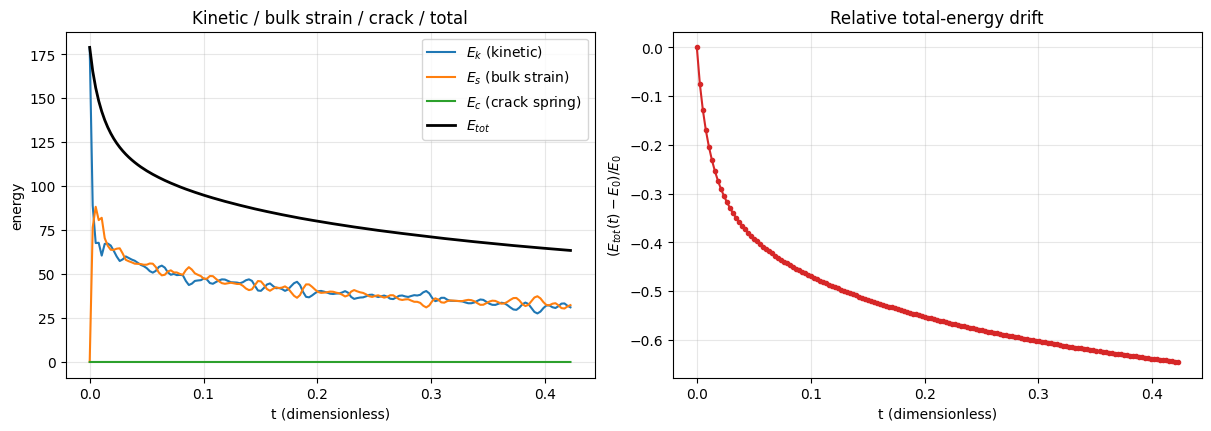

E_k(0)       = 1.789696e+02
E_s(0)       = 0.000000e+00
E_c(0)       = 0.000000e+00
E_tot(0)     = 1.789696e+02
E_tot(t_end) = 6.345583e+01
max |drift|  = 6.454e-01


In [9]:
M_v = A_dyn.tocsr()[velocity_slice, velocity_slice]
Kuu_bulk = poro.Kuu.tocsr()
T_inv = poro._T_inv.tocsr()

# ---------------------------------------------------------------
# Interface spring stiffness.  With nodal enforcement the spring
# block is zero in poro.Kuu (it is pushed into the algebraic
# constraint lambda_sigma = K [[u]]), so the elastic energy stored
# at the interface is missing from 0.5 u^T K_uu u.  We reassemble
# the same problem in 'weak' mode and subtract the bulk Kuu; the
# difference is exactly the spring matrix
#   Kuu_spring = B_plus^T (k_n n n^T + k_t t t^T) M_Gamma B_plus - (+/- terms).
# ---------------------------------------------------------------
poro_weak = CGPoroelastostatics(
    mesh=mesh,
    element_p=el_p,
    element_u=el_u,
    params=params,
    crack=crack,
    crack_model=crack_model,
    intorder=6,
    scales=(SCALE_L, SCALE_EPS),
    bc=bc,
    P_scale=P_SCALE,
    verbose=False,
    free_memory=False,
    enforcement_type='weak',
    apply_transform=False,
    include_taylor=False,
    include_hessian=False,
    include_sbm=False,
    density=1.0,
)
Kuu_spring = (poro_weak.Kuu - Kuu_bulk).tocsr()
print(f"||Kuu_spring||_F = {sp.linalg.norm(Kuu_spring, 'fro'):.3e}")

n_t = len(t_vals)
E_k = np.zeros(n_t)
E_s = np.zeros(n_t)
E_c = np.zeros(n_t)

for i in range(n_t):
    yi = y_vals[i]
    v_i = yi[velocity_slice]
    z_i = yi[:n_base]
    u_phys_i = (T_inv @ z_i)[Np:Np + Nu]
    E_k[i] = 0.5 * float(v_i @ (M_v @ v_i))
    E_s[i] = 0.5 * float(u_phys_i @ (Kuu_bulk @ u_phys_i))
    E_c[i] = 0.5 * float(u_phys_i @ (Kuu_spring @ u_phys_i))

E_tot = E_k + E_s + E_c
E0 = E_tot[0]
E_drift = (E_tot - E0) / E0 if E0 > 0 else E_tot - E0

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(12, 4.2), constrained_layout=True)
ax0.plot(t_vals, E_k,   label='$E_k$ (kinetic)',      color='tab:blue')
ax0.plot(t_vals, E_s,   label='$E_s$ (bulk strain)',  color='tab:orange')
ax0.plot(t_vals, E_c,   label='$E_c$ (crack spring)', color='tab:green')
ax0.plot(t_vals, E_tot, label='$E_{tot}$',            color='k', lw=2)
ax0.set_xlabel('t (dimensionless)')
ax0.set_ylabel('energy')
ax0.set_title('Kinetic / bulk strain / crack / total')
ax0.grid(alpha=0.3); ax0.legend()

ax1.plot(t_vals, E_drift, 'o-', ms=3, color='tab:red')
ax1.set_xlabel('t (dimensionless)')
ax1.set_ylabel(r'$(E_{tot}(t) - E_0)/E_0$')
ax1.set_title('Relative total-energy drift')
ax1.grid(alpha=0.3)
plt.show()

print(f"E_k(0)       = {E_k[0]:.6e}")
print(f"E_s(0)       = {E_s[0]:.6e}")
print(f"E_c(0)       = {E_c[0]:.6e}")
print(f"E_tot(0)     = {E_tot[0]:.6e}")
print(f"E_tot(t_end) = {E_tot[-1]:.6e}")
print(f"max |drift|  = {np.max(np.abs(E_drift)):.3e}")

## 8a. Boundary Condition Verification

For each domain wall, extract the **constrained** displacement/velocity component (should be identically zero) and the **free** component (unconstrained — shown for context).

| Wall | Constrained | Ideal |
|------|------------|-------|
| left / right | $u_1$, $\dot u_1$ | 0 |
| top / bottom | $u_2$, $\dot u_2$ | 0 |

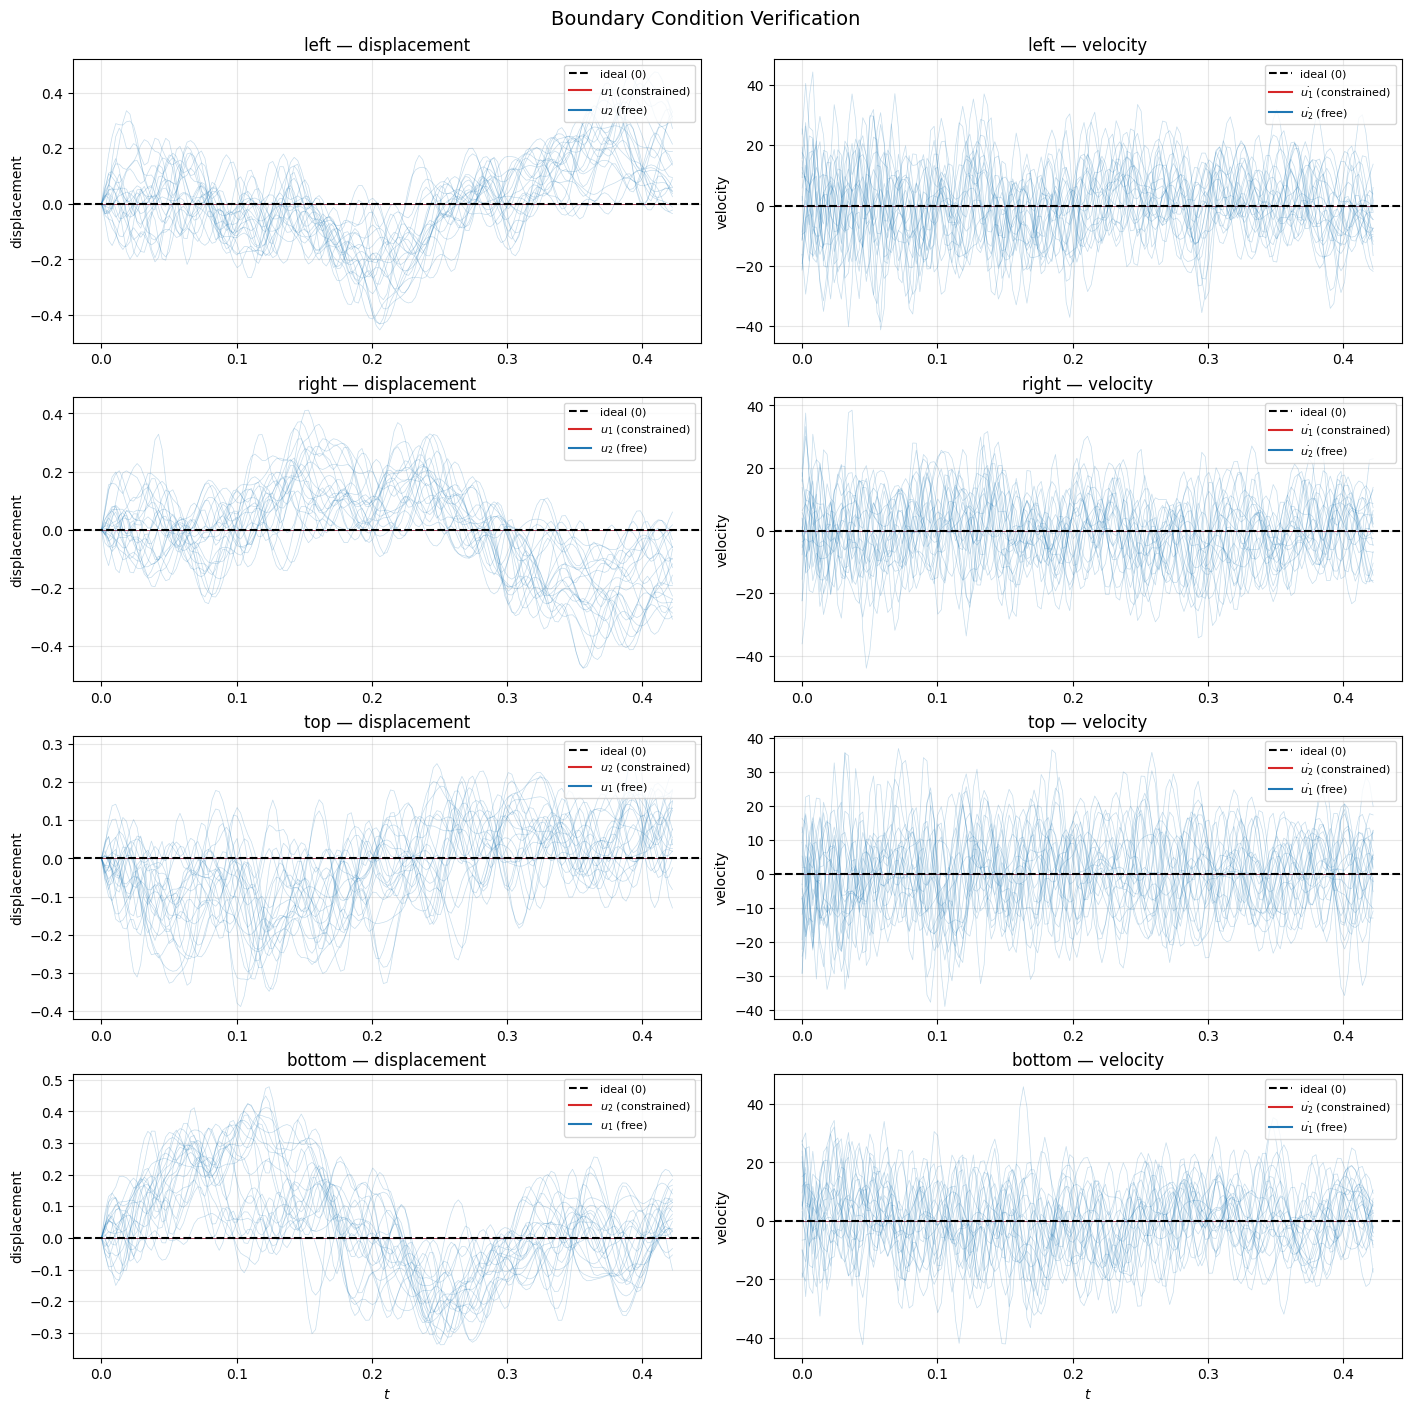

Wall      max|u_constr|  max|v_constr|  #constr DOFs #free DOFs
left          0.000e+00      0.000e+00            25         25
right         0.000e+00      0.000e+00            25         25
top           0.000e+00      0.000e+00            25         25
bottom        0.000e+00      0.000e+00            25         25


In [10]:
bdry_u1 = poro._bdry_dofs_u1   # {side: local u₁ DOF indices}
bdry_u2 = poro._bdry_dofs_u2   # {side: local u₂ DOF indices}
T_inv_csr = poro._T_inv.tocsr()

# Pre-compute displacement (physical) and velocity at every time step
u_all = np.zeros((n_t, Nu))
v_all = np.zeros((n_t, Nu))
for i in range(n_t):
    u_all[i] = (T_inv_csr @ y_vals[i, :n_base])[Np:Np + Nu]
    v_all[i] = y_vals[i, n_base:]

# (side, constrained_label, constrained_dofs, free_label, free_dofs)
boundaries = [
    ('left',   '$u_1$', bdry_u1['left'],   '$u_2$', bdry_u2['left']),
    ('right',  '$u_1$', bdry_u1['right'],  '$u_2$', bdry_u2['right']),
    ('top',    '$u_2$', bdry_u2['top'],    '$u_1$', bdry_u1['top']),
    ('bottom', '$u_2$', bdry_u2['bottom'], '$u_1$', bdry_u1['bottom']),
]

fig, axes = plt.subplots(4, 2, figsize=(14, 14), constrained_layout=True)

for row, (side, c_lab, c_dofs, f_lab, f_dofs) in enumerate(boundaries):
    # --- displacement ---
    ax_d = axes[row, 0]
    for d in c_dofs:
        ax_d.plot(t_vals, u_all[:, d], color='tab:red', alpha=0.35, lw=0.7)
    for d in f_dofs:
        ax_d.plot(t_vals, u_all[:, d], color='tab:blue', alpha=0.25, lw=0.5)
    ax_d.axhline(0, color='k', ls='--', lw=1.5, label='ideal (0)')
    ax_d.plot([], [], color='tab:red', lw=1.5, label=f'{c_lab} (constrained)')
    ax_d.plot([], [], color='tab:blue', lw=1.5, label=f'{f_lab} (free)')
    ax_d.set_ylabel('displacement')
    ax_d.set_title(f'{side} — displacement')
    ax_d.legend(fontsize=8, loc='upper right')
    ax_d.grid(alpha=0.3)

    # --- velocity ---
    ax_v = axes[row, 1]
    for d in c_dofs:
        ax_v.plot(t_vals, v_all[:, d], color='tab:red', alpha=0.35, lw=0.7)
    for d in f_dofs:
        ax_v.plot(t_vals, v_all[:, d], color='tab:blue', alpha=0.25, lw=0.5)
    ax_v.axhline(0, color='k', ls='--', lw=1.5, label='ideal (0)')
    ax_v.plot([], [], color='tab:red', lw=1.5, label=f'$\\dot{{{c_lab[1:-1]}}}$ (constrained)')
    ax_v.plot([], [], color='tab:blue', lw=1.5, label=f'$\\dot{{{f_lab[1:-1]}}}$ (free)')
    ax_v.set_ylabel('velocity')
    ax_v.set_title(f'{side} — velocity')
    ax_v.legend(fontsize=8, loc='upper right')
    ax_v.grid(alpha=0.3)

axes[-1, 0].set_xlabel('$t$')
axes[-1, 1].set_xlabel('$t$')
fig.suptitle('Boundary Condition Verification', fontsize=14)
plt.show()

# Summary table
print(f"{'Wall':<8} {'max|u_constr|':>14} {'max|v_constr|':>14}  "
      f"{'#constr DOFs':>12} {'#free DOFs':>10}")
for side, c_lab, c_dofs, f_lab, f_dofs in boundaries:
    mu = np.max(np.abs(u_all[:, c_dofs])) if len(c_dofs) else 0.0
    mv = np.max(np.abs(v_all[:, c_dofs])) if len(c_dofs) else 0.0
    print(f"{side:<8} {mu:14.3e} {mv:14.3e}  {len(c_dofs):12d} {len(f_dofs):10d}")

## 9. Dashboard

Assemble a fields dictionary via `sol_to_fields_dict_with_dimensions` from the $z$-block of every time slice (the velocity block is dropped here — the dashboard consumes quasi-static fields), then hand it to `CGPoroelasticDashboard` for interactive exploration of displacement, stress, and the crack-interface quantities.

In [11]:
z_vals = y_vals[:, :n_base]   # shape (n_t, n_base)

fields = poro.sol_to_fields_dict_with_dimensions(
    np.asarray(t_vals),
    z_vals.T,
    use_taylor_correction=False,
    constrained_l2=False,
)
fields['y_raw'] = z_vals.T
fields['t_raw'] = np.asarray(t_vals)

dashboard = CGPoroelasticDashboard(poro, fields, levels=40)
dashboard.show()

## 10. Normal/Tangential Rotation — Theory and Verification

This section verifies that rotating crack-interface vector DOFs from Cartesian $(x,y)$ to crack-aligned $(n,t)$ coordinates is a pure change of variables: the **physical solution is identical** to machine precision.

### 10.1 Original (per-side) state vector

After FE discretisation on the cracked mesh, the unknowns are

$$y = \bigl[\,p,\; u,\; \lambda_q^+,\; \lambda_q^-,\; \lambda_\sigma^+,\; \lambda_\sigma^-\,\bigr]$$

| Block | Size | Description |
|-------|------|-------------|
| $p$ | $N_p$ | Nodal pressures |
| $u$ | $N_u$ | Nodal displacements in $(x,y)$, vector field |
| $\lambda_q^\pm$ | $n_c$ each | Flux Lagrange multipliers on crack $\pm$ sides |
| $\lambda_\sigma^\pm$ | $n_{cs}$ each | Traction Lagrange multipliers on crack $\pm$ sides |

Crack nodes appear in **both** $p$ and $u$ (once per side), so these blocks already encode $p^+, p^-$ and $u^+, u^-$.

### 10.2 Transformation 1 — jump/average change of variables

A column-only substitution $y = T_{\text{inv}}\, z$ reorganises the interface DOFs into physically meaningful averages and jumps:

$$z = \bigl[\,p_b,\; u_b,\; \{\!\{p\}\!\},\; [\![p]\!],\; \{\!\{u\}\!\},\; [\![u]\!],\; \{\!\{\lambda_q\}\!\},\; [\![\lambda_q]\!],\; \{\!\{\lambda_\sigma\}\!\},\; [\![\lambda_\sigma]\!]\,\bigr]$$

with $\{\!\{f\}\!\} = \tfrac12(f^+ + f^-)$ and $[\![f]\!] = f^+ - f^-$.  The bulk DOFs $p_b, u_b$ (those not on the crack) pass through unchanged.

**Matrix update** (column-only):

$$A \to A\,T_{\text{inv}}, \qquad M \to M\,T_{\text{inv}}$$

The equation-space (row layout) is unchanged — $T_{\text{inv}}$ acts only on the trial side.

### 10.3 Transformation 2 — $(x,y) \to (n,t)$ rotation

When `rotate_crack_to_nt=True`, the **vector** interface DOFs are further rotated from Cartesian to crack-aligned coordinates.  At each interface node $k$ with outward normal $\hat n_k = (n_x, n_y)$ and tangent $\hat t_k = (-n_y, n_x)$, the per-node rotation is

$$R_k = \begin{pmatrix} n_x & n_y \\ -n_y & n_x \end{pmatrix}, \qquad R_k^T R_k = I.$$

These are assembled into a block-diagonal matrix $R_{\text{block}}$ of size $N \times N$ acting on the full state:

| Block | Rotation applied |
|-------|-----------------|
| $p_b$, $u_b$, $\{\!\{p\}\!\}$, $[\![p]\!]$, $\{\!\{\lambda_q\}\!\}$, $[\![\lambda_q]\!]$ | Identity (scalar blocks) |
| $\{\!\{u\}\!\}$, $[\![u]\!]$, $\{\!\{\lambda_\sigma\}\!\}$, $[\![\lambda_\sigma]\!]$ | $R_{nt}$ per node |

The rotated state is $\tilde z = R_{\text{block}}\, z$, so the overall column map becomes

$$y = T_{\text{inv}}\, R_{\text{block}}^T\, \tilde z = \tilde T_{\text{inv}}\, \tilde z.$$

The rotated state vector exposes normal/tangential components explicitly:

$$\tilde z = \bigl[\,p_b,\; u_b,\; \{\!\{p\}\!\},\; [\![p]\!],\; \{\!\{u_n\}\!\},\; \{\!\{u_t\}\!\},\; [\![u_n]\!],\; [\![u_t]\!],\; \{\!\{\lambda_q\}\!\},\; [\![\lambda_q]\!],\; \{\!\{\sigma_n\}\!\},\; \{\!\{\tau\}\!\},\; [\![\sigma_n]\!],\; [\![\tau]\!]\,\bigr]$$

**Matrix update:**

$$\tilde A = A\, T_{\text{inv}}\, R_{\text{block}}^T, \qquad \tilde M = M\, T_{\text{inv}}\, R_{\text{block}}^T$$

### 10.4 Transformation 3 — first-order dynamic extension

The quasi-static DAE is lifted to a descriptor system by introducing an explicit velocity block $v$:

$$x = [z,\; v], \qquad A_{\text{dyn}}\, \dot x = \text{rhs}_{\text{dyn}}(t, x).$$

| Row block | $A_{\text{dyn}}$ entry | RHS / Jacobian entry |
|-----------|----------------------|----------------------|
| Pressure (mass balance) | $M_p\, \dot z$ (u-columns zeroed) | $-A_p\, z - M_{pu}\, v$ |
| Kinematic ($\dot z_u = T_u v$) | $I_{kz}\, \dot z$ | $T_u\, v$ |
| Multiplier (algebraic) | $0$ | $-A_\lambda\, z$ (filled by projection) |
| Momentum ($M_u \dot v$) | $M_{u,\text{eff}}\, \dot v$ | $J_{\text{mom},z}\, z - M_{\text{damp}}\, v$ |

When `rotate_crack_to_nt=True`, the velocity block is also rotated by a **separate** scattered rotation $R_v$ (`build_R_velocity`) that applies $R_k$ at every crack interface displacement DOF (both $\pm$ sides), and identity at interior DOFs.  The rotated quantities are:

- $M_{u,\text{eff}} \to R_v\, M_{u,\text{eff}}\, R_v^T$ — inertia conjugated into $(n,t)$ frame
- $T_u \to T_u\, R_v^T$ — absorbs inverse rotation so $\dot z_u = T_u\, v_{nt}$ still maps correctly
- $J_{\text{mom},z} \to R_v\, J_{\text{mom},z}$ — stiffness rotated on the left
- $M_{\text{damp}} \to R_v\, M_{\text{damp}}$ — damping rotated on the left

Since $R_v$ is orthogonal, this is again a pure change of variables.  The physical displacement $u_{\text{phys}} = T_{\text{inv}}\, z$ is unchanged, and the physical velocity is recovered by $v_{xy} = R_v^T\, v_{nt}$.

### 10.5 What this cell verifies

1. **Transform roundtrip:** $\|T_{\text{inv}}\, T - I\| / N \sim 10^{-36}$ and $R_{\text{block}}^T R_{\text{block}} = I$ exactly.
2. **IC equivalence:** Physical displacements at $t=0$ are identical (zero IC in both).
3. **Descriptor structure:** Same matrix dimensions; $\text{nnz}$ may differ slightly due to rotation fill-in in $R_{nt}$.
4. **Time-stepping equivalence (Section 10a):** After 161 Radau IIA steps, all physical fields agree to $\mathcal O(10^{-12})$ relative error — confirming the rotation is exact to machine precision accumulated over iterative Newton solves.

In [12]:
# Rebuild with (n,t) rotation
poro_nt = CGPoroelastostatics(
    mesh=mesh, element_p=el_p, element_u=el_u,
    params=params, crack=crack, crack_model=crack_model,
    intorder=6, scales=(SCALE_L, SCALE_EPS), bc=bc,
    P_scale=P_SCALE, verbose=True, free_memory=False,
    enforcement_type=ENFORCEMENT_TYPE, apply_transform=True,
    include_taylor=False, include_hessian=False, include_sbm=False,
    density=1.0, rotate_crack_to_nt=True,
)
poro_nt.rho_d = float(RHO_D)

poro_nt.strip_multiplier_dynamics()
proj_nt, meta_nt = poro_nt.build_projection()
dyn_nt = poro_nt.build_first_order_dynamic_system(
    meta_nt, projection=proj_nt, density=1.0)

# 1. Transform roundtrip
T_nt = poro_nt._T
T_inv_nt = poro_nt._T_inv
n = T_nt.shape[0]
err_l = sp.linalg.norm(T_inv_nt @ T_nt - sp.eye(n)) / n
err_r = sp.linalg.norm(T_nt @ T_inv_nt - sp.eye(n)) / n
print(f"Transform roundtrip:  ||T_inv T - I||/n = {err_l:.2e},  ||T T_inv - I||/n = {err_r:.2e}")

# 2. Physical displacement match at IC
y0_nt_base = poro_nt.get_consistent_ic(np.zeros(poro_nt.ndofs))
u0_xy = (poro._T_inv @ y0_base)[Np:Np + Nu]
u0_nt = (poro_nt._T_inv @ y0_nt_base)[Np:Np + Nu]
print(f"IC displacement match: max|diff| = {np.max(np.abs(u0_nt - u0_xy)):.2e}")

# 3. Descriptor pencil structure
A_nt = dyn_nt['A']
print(f"\nDescriptor size:  (x,y) = {A_dyn.shape},  (n,t) = {A_nt.shape}")
print(f"Descriptor nnz:   (x,y) = {A_dyn.nnz},  (n,t) = {A_nt.nnz}")

# 4. Rotation flag
print(f"rotated_to_nt = {poro_nt._transform_info.get('rotated_to_nt')}")
R_block = poro_nt._transform_info.get('R_block')
if R_block is not None:
    print(f"R_block shape = {R_block.shape}, orthogonality error = "
          f"{sp.linalg.norm(R_block @ R_block.T - sp.eye(R_block.shape[0])):.2e}")

Mesh split along crack:
  Original: 798 vertices, 1498 elements
  Split: 809 vertices, 1498 elements
  Crack facets: 12 plus, 12 minus
  Projected 0 / 48 QPs with flipped normals for basis <skfem FacetBasis(MeshTri1, ElementTriP1) object>
  Number of elements: 12
  Number of DOFs: 809
  Size: 3456 B
  Projected 0 / 48 QPs with flipped normals for basis <poroelasticity.cg_crack_assembler.FlippedNormalBasis object at 0x7bdeaee01150>
  Projected 0 / 48 QPs with flipped normals for basis <skfem FacetBasis(MeshTri1, ElementVector) object>
  Number of elements: 12
  Number of DOFs: 4614
  Size: 18432 B
  Projected 0 / 48 QPs with flipped normals for basis <poroelasticity.cg_crack_assembler.FlippedNormalBasis object at 0x7bdeae603450>
SBM geometry cache: 192 QPs pre-computed in 2.1 ms
Crack interface assembled (Spring law + SBM corrections):
  Robin T = 0.00e+00 (dimensionless: 0.00e+00)
  Spring k_n = 100000000.0 (dimensionless: 3.40e+04)
  Spring k_t = 100000000.0 (dimensionless: 3.40e+04)


Transform roundtrip:  ||T_inv T - I||/n = 2.27e-36,  ||T T_inv - I||/n = 0.00e+00
IC displacement match: max|diff| = 0.00e+00

Descriptor size:  (x,y) = (10103, 10103),  (n,t) = (10103, 10103)
Descriptor nnz:   (x,y) = 40775,  (n,t) = 41247
rotated_to_nt = True
R_block shape = (5489, 5489), orthogonality error = 0.00e+00


### 10a. Time-stepping equivalence

Run the full dynamic simulation with the (n,t) rotated solver using the same IC, integrator, and step size. Compare the physical displacement, pressure, and velocity fields at every time step against the (x,y) results from section 7.

Solving (n,t) rotated system: Radau IIA s=2, h=2.639e-03, ~160 steps


Done: 161 steps, t_final = 4.2220e-01

Time-stepping equivalence: (x,y) vs (n,t) rotated system
  Steps compared:           161
  max |u_xy - u_nt| over all steps: 1.267e-12
  max |p_xy - p_nt| over all steps: 4.874e-10
  max |v_xy - v_nt| over all steps: 9.666e-10

  Relative (displacement): 2.652e-12  (ref |u|_max = 4.777e-01)
  Relative (velocity):     1.646e-11  (ref |v|_max = 5.874e+01)


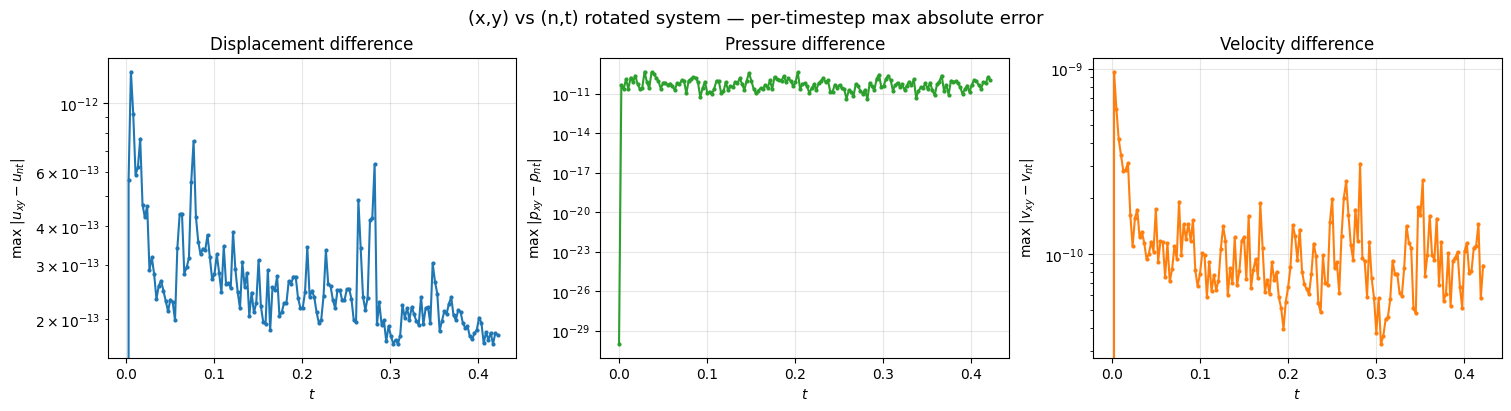

In [13]:
# --- Rotated IC ---
# The base-block IC lives in (n,t) transformed coordinates.
# The velocity block is NOW in (n,t) coordinates too (Phase 1 rotation).
y0_nt_base = poro_nt.get_consistent_ic(np.zeros(poro_nt.ndofs))
R_v = dyn_nt.get('R_v')
v_kick_nt = (R_v @ v_kick) if R_v is not None else v_kick
y0_nt = np.concatenate([y0_nt_base, v_kick_nt])

# --- Solver options (mirror section 7 exactly) ---
A_nt      = dyn_nt['A']
rhs_nt    = dyn_nt['rhs']
rhs_jac_nt = dyn_nt['rhs_jac']
comp_sl_nt = dyn_nt['component_slices']
nl_atol_nt = dyn_nt['nl_atol_per_block']

solver_opts_nt = dict(meta_nt['solver_opts'])
solver_opts_nt['rhs_jac'] = rhs_jac_nt
solver_opts_nt['linear_solver'] = 'petsc'
solver_opts_nt['precond_reuse_steps'] = 1_000_000
solver_opts_nt['petsc_options'] = {
    **solver_opts_nt.get('petsc_options', {}),
    'mat_mumps_icntl_23': 0,
}

# --- Solve ---
print(f"Solving (n,t) rotated system: Radau IIA s=2, h={h_fixed:.3e}, ~{int(tmax / h_fixed)} steps")

t_nt, y_nt, *_ = solve_nivp.solve_ivp_ns(
    fun=rhs_nt,
    t_span=(0, tmax),
    y0=y0_nt,
    method='radau_iia',
    integrator_opts={'stages': 2, 'wf_maxiter': 3, 'use_coupled_newton': True},
    projection=proj_nt,
    solver='semismooth_newton',
    projection_opts={'rhok': 1.0, 'component_slices': comp_sl_nt},
    solver_opts=solver_opts_nt,
    adaptive=False, h0=h_fixed,
    nl_atol=nl_atol_nt, nl_rtol=1e-6,
    component_slices=comp_sl_nt,
    verbose=True,
    A=A_nt,
)
print(f"Done: {len(t_nt)} steps, t_final = {t_nt[-1]:.4e}")

# --- Compare physical fields at every timestep ---
T_inv_xy = poro._T_inv.tocsr()
T_inv_nt_csr = poro_nt._T_inv.tocsr()

n_steps = min(len(t_vals), len(t_nt))
max_u_diff = np.zeros(n_steps)
max_p_diff = np.zeros(n_steps)
max_v_diff = np.zeros(n_steps)

for i in range(n_steps):
    # Physical fields from (x,y) solve
    phys_xy = T_inv_xy @ y_vals[i, :n_base]
    p_xy = phys_xy[:Np]
    u_xy = phys_xy[Np:Np + Nu]
    v_xy = y_vals[i, n_base:]

    # Physical fields from (n,t) solve — recover (x,y) velocity via R_v^T
    phys_nt = T_inv_nt_csr @ y_nt[i, :n_base]
    p_nt = phys_nt[:Np]
    u_nt = phys_nt[Np:Np + Nu]
    v_nt_raw = y_nt[i, n_base:]
    v_nt = (R_v.T @ v_nt_raw) if R_v is not None else v_nt_raw

    max_u_diff[i] = np.max(np.abs(u_xy - u_nt))
    max_p_diff[i] = np.max(np.abs(p_xy - p_nt))
    max_v_diff[i] = np.max(np.abs(v_xy - v_nt))

# --- Report ---
print(f"\n{'='*60}")
print(f"Time-stepping equivalence: (x,y) vs (n,t) rotated system")
print(f"{'='*60}")
print(f"  Steps compared:           {n_steps}")
print(f"  max |u_xy - u_nt| over all steps: {np.max(max_u_diff):.3e}")
print(f"  max |p_xy - p_nt| over all steps: {np.max(max_p_diff):.3e}")
print(f"  max |v_xy - v_nt| over all steps: {np.max(max_v_diff):.3e}")

# Normalise by field magnitudes for context
u_scale = np.max(np.abs(np.array([T_inv_xy @ y_vals[i, :n_base]
                                   for i in range(n_steps)])[:, Np:Np+Nu]))
v_scale = np.max(np.abs(y_vals[:n_steps, n_base:]))
print(f"\n  Relative (displacement): {np.max(max_u_diff) / u_scale:.3e}  "
      f"(ref |u|_max = {u_scale:.3e})")
print(f"  Relative (velocity):     {np.max(max_v_diff) / v_scale:.3e}  "
      f"(ref |v|_max = {v_scale:.3e})")

fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)

axes[0].semilogy(t_nt[:n_steps], max_u_diff, 'o-', ms=2, color='tab:blue')
axes[0].set_xlabel('$t$'); axes[0].set_ylabel('max $|u_{xy} - u_{nt}|$')
axes[0].set_title('Displacement difference'); axes[0].grid(alpha=0.3)

axes[1].semilogy(t_nt[:n_steps], max_p_diff + 1e-30, 'o-', ms=2, color='tab:green')
axes[1].set_xlabel('$t$'); axes[1].set_ylabel('max $|p_{xy} - p_{nt}|$')
axes[1].set_title('Pressure difference'); axes[1].grid(alpha=0.3)

axes[2].semilogy(t_nt[:n_steps], max_v_diff, 'o-', ms=2, color='tab:orange')
axes[2].set_xlabel('$t$'); axes[2].set_ylabel('max $|v_{xy} - v_{nt}|$')
axes[2].set_title('Velocity difference'); axes[2].grid(alpha=0.3)

fig.suptitle('(x,y) vs (n,t) rotated system — per-timestep max absolute error', fontsize=13)
plt.show()

## 11. Work-Conjugacy: Traction Distribution B vs Jump Extraction D

In the descriptor dynamic system, two matrices govern the interface coupling:

| Matrix | Definition | Role |
|--------|-----------|------|
| $D$ | Rows of $T_u$ at $[\![u]\!]$ block positions | Extracts velocity jumps: $[\![\dot u]\!] = D\,v$ |
| $B$ | Columns of $J_{\text{mom},z}$ at $[\![\lambda_\sigma]\!]$ positions | Distributes tractions: $\text{force} = B\,[\![\lambda_\sigma]\!]$ |

**Pointwise work-conjugacy** requires $B = D^T$, so that $\delta v^T B\,\lambda = (D\,\delta v)^T \lambda$ for all $\delta v, \lambda$.

### Derivation

After the column-only transform $A_{\text{new}} = A_{\text{orig}} T_{\text{inv}}$, the traction distribution matrix is:

$$B = -A_{\text{new}}[\text{row}_u,\; [\![\lambda_\sigma]\!]] = \tfrac12\bigl(G_{u,-} - G_{u,+}\bigr)$$

where $G_{u,\pm}$ are the per-side traction coupling matrices from the augmented stiffness (row 1, blocks 4–5).

With the default `lumped_coupling=True`, $G_{u,\pm}$ are **diagonal scatters** with weight $h$ (the lumped integration weight at each interface node).  Since plus-side and minus-side DOFs are disjoint after mesh splitting:

$$B = -\tfrac{h}{2}\,D^T$$

The factor $-h/2$ has two parts: $h$ converts traction flux $[\mathrm{force/length}]$ to a nodal force, and $-\tfrac12$ comes from the $T_{\text{inv}}$ mapping $\lambda^\pm = \{\!\{\lambda\}\!\} \pm \tfrac12[\![\lambda]\!]$.

### What this cell verifies

1. $B \neq D^T$ (the raw matrices differ by the scale factor $-h/2$)
2. $B = D^T M_\Gamma$ exactly, where $M_\Gamma = -\tfrac{h}{2}\,I$ is a **scalar** interface mass matrix
3. The virtual power ratio $v^T B \lambda\,/\,(Dv)^T \lambda = -h/2$ is constant for all test fields

In [ ]:
def check_work_conjugacy(poro_obj, dyn_dict, label):
    info = poro_obj._transform_info
    Np = poro_obj.basis_p.N
    Nu = poro_obj.basis_u.N
    T_u_mat = dyn_dict['T_u']
    R_v_mat = dyn_dict['R_v']
    u_idx = dyn_dict['u_state_indices']

    # --- D: kinematic extraction of [[v]] from velocity ---
    off_jmpu = info['off_jmpu']
    n_iu = info['n_intf_u']
    jmpu_global = np.arange(off_jmpu, off_jmpu + n_iu)
    jmpu_local = np.searchsorted(u_idx, jmpu_global)
    assert np.all(u_idx[jmpu_local] == jmpu_global), "[[u]] not in u_state"
    D = T_u_mat[jmpu_local, :].toarray()

    # --- B: traction distribution from momentum Jacobian ---
    off_jmpls = info['off_jmpls']
    n_ls = info['n_lam_sig']
    jmpls_cols = np.arange(off_jmpls, off_jmpls + n_ls)
    A_csr = poro_obj.A.tocsr()
    B = -(A_csr[Np:Np + Nu, :][:, jmpls_cols]).toarray()
    if R_v_mat is not None:
        B = R_v_mat.toarray() @ B

    norm_B = np.linalg.norm(B, 'fro')

    print(f"=== {label} ===")
    print(f"  D: {D.shape}  (n_iu x Nu)")
    print(f"  B: {B.shape}  (Nu x n_ls)")

    # --- Check 1: B = D^T ? ---
    err_BDT = np.linalg.norm(B - D.T, 'fro')
    print(f"\n  [Check 1] B = D^T  (pointwise)")
    print(f"    ||B - D^T||_F / ||B||_F = {err_BDT / norm_B:.6e}")

    # --- Check 2: B = -(h/2) D^T ? ---
    scale = -h / 2.0
    err_scaled = np.linalg.norm(B - scale * D.T, 'fro')
    print(f"\n  [Check 2] B = -(h/2) D^T  (predicted scalar relationship)")
    print(f"    h = {h:.6f},  -h/2 = {scale:.6f}")
    print(f"    ||B - (-h/2) D^T||_F / ||B||_F = {err_scaled / norm_B:.6e}")
    if err_scaled / norm_B < 1e-12:
        print(f"    --> PASS")
    else:
        print(f"    --> FAIL")

    # --- Check 3: B = D^T M_Gamma (general factorization) ---
    DDT = D @ D.T
    M_gamma = np.linalg.solve(DDT, D @ B)
    B_recon = D.T @ M_gamma
    err_recon = np.linalg.norm(B - B_recon, 'fro')
    print(f"\n  [Check 3] B = D^T M_Gamma  (general factorization)")
    print(f"    ||B - D^T M_Gamma||_F / ||B||_F = {err_recon / norm_B:.6e}")

    eigs = np.linalg.eigvalsh(0.5 * (M_gamma + M_gamma.T))
    is_scalar = (eigs.max() - eigs.min()) / max(abs(eigs.max()), 1e-30) < 1e-12
    off_diag = np.max(np.abs(M_gamma - np.diag(np.diag(M_gamma))))
    print(f"    M_Gamma diagonal: [{np.diag(M_gamma).min():.10f}, "
          f"{np.diag(M_gamma).max():.10f}]")
    print(f"    M_Gamma off-diagonal max: {off_diag:.2e}")
    print(f"    scalar matrix: {is_scalar}  (all eigenvalues equal)")

    # --- Check 4: virtual power ratio ---
    rng = np.random.default_rng(42)
    ratios = []
    for _ in range(50):
        v_test = rng.standard_normal(Nu)
        lam_test = rng.standard_normal(n_ls)
        P_B = float(v_test @ B @ lam_test)
        P_D = float((D @ v_test) @ lam_test)
        if abs(P_D) > 1e-30:
            ratios.append(P_B / P_D)
    ratios = np.array(ratios)
    print(f"\n  [Check 4] Virtual power ratio  v^T B lam / (Dv)^T lam")
    print(f"    mean  = {ratios.mean():.10f}   (predicted: {scale:.10f})")
    print(f"    std   = {ratios.std():.2e}")
    print(f"    match: {abs(ratios.mean() - scale) < 1e-12}")

    return D, B, M_gamma


D_xy, B_xy, Mg_xy = check_work_conjugacy(poro, dyn, '(x,y) system')
print()
D_nt, B_nt, Mg_nt = check_work_conjugacy(poro_nt, dyn_nt, '(n,t) rotated system')